In [ ]:
import os
import shutil
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import kagglehub

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Fruits360 (Food)
fruits_path = kagglehub.dataset_download("moltean/fruits")
print("Fruits360 downloaded at:", fruits_path)

# TrashNet (Non-Food)
trashnet_path = kagglehub.dataset_download("feyzazkefe/trashnet")
print("TrashNet downloaded at:", trashnet_path)

100%|██████████| 4.36G/4.36G [03:17<00:00, 23.7MB/s]

Extracting files...


Fruits360 downloaded at: /root/.cache/kagglehub/datasets/moltean/fruits/versions/57
Using Colab cache for faster access to the 'trashnet' dataset.
TrashNet downloaded at: /kaggle/input/trashnet


In [ ]:
print("Contents of Fruits360:", os.listdir(fruits_path))

Contents of Fruits360: ['fruits-360_3-body-problem', 'fruits-360_multi', 'fruits-360_dataset_meta', 'fruits-360_100x100', 'fruits-360_original-size']


In [ ]:
print("Contents of Fruits360:", os.listdir(trashnet_path))

Contents of Fruits360: ['dataset-resized']


In [ ]:
fruits_root = os.path.join(fruits_path, "fruits-360_100x100", "fruits-360")
print("Fruits360 (100x100) Path:", fruits_root)
print("Contents:", os.listdir(fruits_root))

Fruits360 (100x100) Path: /root/.cache/kagglehub/datasets/moltean/fruits/versions/57/fruits-360_100x100/fruits-360
Contents: ['Test', 'Training', 'README.md', 'LICENSE']


In [ ]:
# Copy Fruits360 as 'food'
dst_food = "/content/food"
shutil.copytree(fruits_root, dst_food, dirs_exist_ok=True)
print("Fruits360 (100x100) saved as /content/food")

Fruits360 (100x100) saved as /content/food


In [ ]:
# Copy TrashNet as 'non_food'
src_trashnet = os.path.join(trashnet_path, "dataset-resized")
dst_nonfood = "/content/non_food"
shutil.copytree(src_trashnet, dst_nonfood, dirs_exist_ok=True)
print("TrashNet saved as /content/non_food")

✅ TrashNet saved as /content/non_food


In [ ]:
# Merge Both into One Unified Dataset
parent_dataset = "/content/food_waste_dataset"
food_src = os.path.join(dst_food, "Training")  # Fruits360 Training set
non_food_src = dst_nonfood

food_dst = os.path.join(parent_dataset, "food")
non_food_dst = os.path.join(parent_dataset, "non_food")

shutil.copytree(food_src, food_dst, dirs_exist_ok=True)
shutil.copytree(non_food_src, non_food_dst, dirs_exist_ok=True)

print("Merged dataset created at:", parent_dataset)
print("Food classes:", len(os.listdir(food_dst)))
print("Non-food classes:", len(os.listdir(non_food_dst)))

Merged dataset created at: /content/food_waste_dataset
Food classes: 221
Non-food classes: 6


In [ ]:
def show_samples(base_path, num_classes=5, samples_per_class=5):
    classes = os.listdir(base_path)[:num_classes]
    for c in classes:
        class_path = os.path.join(base_path, c)
        images = os.listdir(class_path)[:samples_per_class]
        plt.figure(figsize=(4, 4))
        plt.subplots_adjust(top=0.85, wspace=0.05)
        plt.suptitle(f"{c}", fontsize=12, y=0.65)

        for i, img_name in enumerate(images):
            img_path = os.path.join(class_path, img_name)
            img = mpimg.imread(img_path)
            plt.subplot(1, samples_per_class, i + 1)
            plt.imshow(img)
            plt.axis("off")

        plt.show()


 Food Samples:


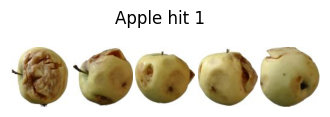

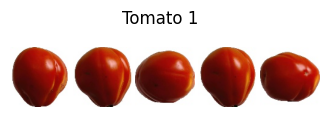

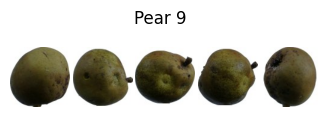

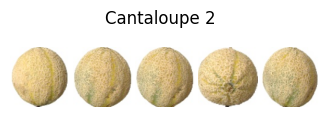

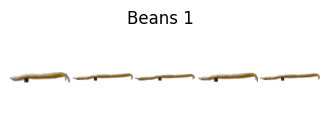

In [ ]:
print("\n Food Samples:")
show_samples(food_dst)


 Non-Food Samples:


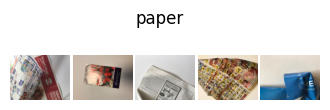

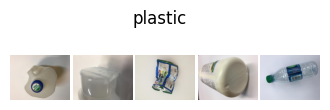

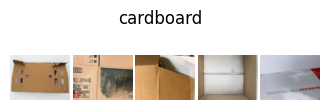

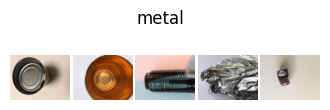

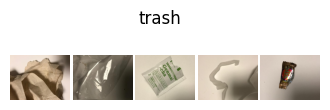

In [ ]:
print("\n Non-Food Samples:")
show_samples(non_food_dst)


 Food Class Distribution:


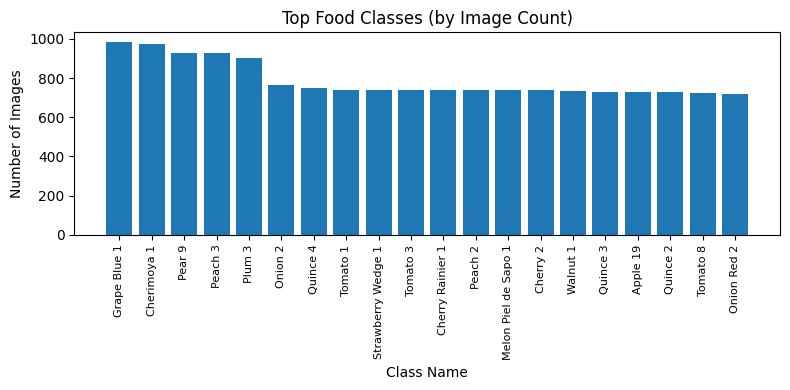


 Non-Food Class Distribution:


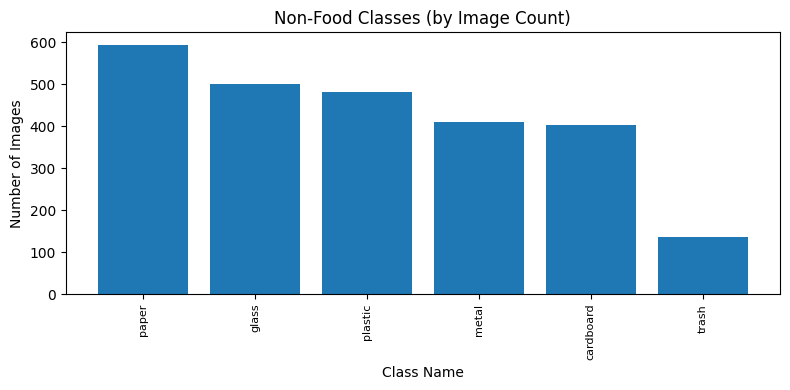

In [ ]:
# Class Distribution Visualization
from collections import defaultdict

def plot_class_distribution(base_path, title, max_classes=20):
    class_counts = defaultdict(int)

    for class_name in os.listdir(base_path):
        class_folder = os.path.join(base_path, class_name)
        if os.path.isdir(class_folder):
            class_counts[class_name] = len(os.listdir(class_folder))

    # Sort by number of images (descending)
    sorted_classes = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))

    # Show only top N classes for clarity
    limited_classes = dict(list(sorted_classes.items())[:max_classes])

    plt.figure(figsize=(8, 4))
    plt.bar(limited_classes.keys(), limited_classes.values())
    plt.xticks(rotation=90, fontsize=8)
    plt.title(title)
    plt.ylabel("Number of Images")
    plt.xlabel("Class Name")
    plt.tight_layout()
    plt.show()


# Visualize both datasets
print("\n Food Class Distribution:")
plot_class_distribution(food_dst, "Top Food Classes (by Image Count)")

print("\n Non-Food Class Distribution:")
plot_class_distribution(non_food_dst, "Non-Food Classes (by Image Count)")

In [ ]:
# Split the merged dataset into train/test folders (80/20)
import random
import shutil
from tqdm import tqdm

base_dir = "/content/food_waste_dataset"
train_dir = "/content/food_waste_dataset_split/train"
test_dir = "/content/food_waste_dataset_split/test"

# Create destination folders
for split_dir in [train_dir, test_dir]:
    for category in ["food", "non_food"]:
        os.makedirs(os.path.join(split_dir, category), exist_ok=True)

# Function to split data
def split_data(source_dir, dest_train, dest_test, split_ratio=0.8):
    for class_name in tqdm(os.listdir(source_dir), desc=f"Splitting {source_dir}"):
        class_path = os.path.join(source_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = os.listdir(class_path)
        random.shuffle(images)

        split_point = int(len(images) * split_ratio)
        train_imgs = images[:split_point]
        test_imgs = images[split_point:]

        # Copy images to respective folders
        for img_list, dest_dir in [(train_imgs, dest_train), (test_imgs, dest_test)]:
            class_dest = os.path.join(dest_dir, class_name)
            os.makedirs(class_dest, exist_ok=True)

            for img_name in img_list:
                src = os.path.join(class_path, img_name)
                dst = os.path.join(class_dest, img_name)
                shutil.copy(src, dst)

# Split food and non_food separately
split_data(os.path.join(base_dir, "food"),
            os.path.join(train_dir, "food"),
            os.path.join(test_dir, "food"))

split_data(os.path.join(base_dir, "non_food"),
            os.path.join(train_dir, "non_food"),
            os.path.join(test_dir, "non_food"))

print("\n Dataset successfully split!")
print(f"Train folder: {train_dir}")
print(f"Test folder: {test_dir}")

# Quick check: number of images in train/test
def count_images(path):
    total = 0
    for root, _, files in os.walk(path):
        total += len([f for f in files if f.lower().endswith(('png', 'jpg', 'jpeg'))])
    return total

print(f"\n Training images: {count_images(train_dir)}")
print(f"\n Testing images: {count_images(test_dir)}")

Splitting /content/food_waste_dataset/non_food: 100%|██████████| 6/6 [00:00<00:00, 19.04it/s]



 Dataset successfully split!
Train folder: /content/food_waste_dataset_split/train
Test folder: /content/food_waste_dataset_split/test

 Training images: 93533

 Testing images: 23476


In [ ]:
# Load dataset with ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths to split dataset
train_dir = "/content/food_waste_dataset_split/train"
test_dir = "/content/food_waste_dataset_split/test"

# Image size (MobileNetV2 default = 128×128 or 224×224)
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Data augmentation + normalization for training
train_datagen = ImageDataGenerator(
    rescale=1./255,            # Normalize pixel values
    rotation_range=20,         # Random rotation
    width_shift_range=0.1,     # Random horizontal shift
    height_shift_range=0.1,    # Random vertical shift
    zoom_range=0.1,            # Random zoom
    horizontal_flip=True,      # Flip left–right
    validation_split=0.2       # 20% of training data used for validation
)

# Train + validation data generators
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

# Test data (no augmentation, only normalization)
test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# Verify class indices
print("\n Class mapping:", train_gen.class_indices)

Found 74828 images belonging to 2 classes.
Found 18705 images belonging to 2 classes.
Found 23476 images belonging to 2 classes.

 Class mapping: {'food': 0, 'non_food': 1}


In [ ]:
# Build and train MobileNetV2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Load base MobileNetV2 with pretrained ImageNet weights
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,         # exclude the top FC layer
    input_shape=(128, 128, 3)
)

# Freeze base model so we only train the top layers initially
base_model.trainable = False

# Add our custom classification layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)  # flatten spatial data
x = Dropout(0.3)(x)              # prevent overfitting
predictions = Dense(train_gen.num_classes, activation='softmax')(x)

# Define full model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Summary of model architecture
model.summary()

# Train model
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    verbose=1
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
2339/2339 ━━━━━━━━━━━━━━━━━━━━ 468s 192ms/step - accuracy: 0.9832 - loss: 0.0525 - val_accuracy: 0.9995 - val_loss: 0.0040
Epoch 2/10
2339/2339 ━━━━━━━━━━━━━━━━━━━━ 431s 184ms/step - accuracy: 0.9994 - loss: 0.0028 - val_accuracy: 0.9997 - val_loss: 0.0017
Epoch 3/10
2339/2339 ━━━━━━━━━━━━━━━━━━━━ 427s 182ms/step - accuracy: 0.9996 - loss: 0.0016 - val_accuracy: 0.9999 - val_loss: 0.0011
Epoch 4/10
2339/2339 ━━━━━━━━━━━━━━━━━━━━ 413s 177ms/step - accuracy: 0.9998 - loss: 7.4536e-04 - val_accuracy: 0.9999 - val_loss: 6.3238e-04
Epoch 5/10
2339/2339 ━━━━━━━━━━━━━━━━━━━━ 415s 178ms/step - accuracy: 0.9999 - loss: 5.6682e-04 - val_accuracy: 0.9998 - val_loss: 7.4346e-04
Epoch 6/10
2339/2339 ━━━━━━━━━━━━━━━━━━━━ 416s 178ms/step - accuracy: 1.0000 - loss: 3.5205e-04 - val_accuracy: 0.9997 - val_loss: 6.8336e-04
Epoch 7/10
2339/2339 ━━━━━━━━━━━━━━━━━━━━ 413s 177ms/step - accuracy: 0.9999 - loss: 2.5938e-04 - val_accuracy: 0.9999 - val_loss: 4.2539e-04
Epoch 8/10
2339/2339 ━━━━━━━━━

In [ ]:
# Evaluate the model
val_loss, val_acc = model.evaluate(val_gen, verbose=1)
print(f"\nValidation Accuracy: {val_acc*100:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")

585/585 ━━━━━━━━━━━━━━━━━━━━ 83s 141ms/step - accuracy: 1.0000 - loss: 1.9998e-04

Validation Accuracy: 99.99%
Validation Loss: 0.0005


1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


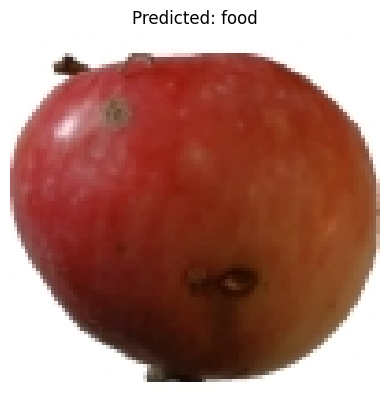

Model prediction: food


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Path to any test image (inside or outside dataset)
test_img_path = "/content/food_waste_dataset/food/Apple 10/r0_0_100.jpg"

# Load and preprocess
img = image.load_img(test_img_path, target_size=(128, 128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
predicted_class = list(train_gen.class_indices.keys())[np.argmax(pred)]

# Display
plt.imshow(image.load_img(test_img_path))
plt.axis('off')
plt.title(f"Predicted: {predicted_class}")
plt.show()

print("Model prediction:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


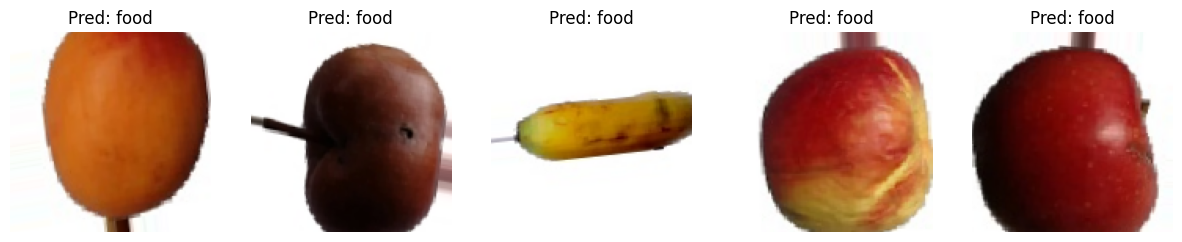

In [ ]:
import random

# Pick 5 random test images from the validation set
batch = next(val_gen)
images, labels = batch

plt.figure(figsize=(15, 8))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    img = images[i]
    label = np.argmax(labels[i])
    pred = np.argmax(model.predict(img[np.newaxis, ...]))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Pred: {list(train_gen.class_indices.keys())[pred]}")
plt.show()

In [ ]:
# Save your trained model
model.save("/content/food_waste_classifier_mobilenetv2.h5")
print("Model saved successfully at: /content/food_waste_classifier_mobilenetv2.h5")

## Reload colab and run this

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("/content/food_waste_classifier_mobilenetv2.h5")
print("Model loaded successfully!")

Model loaded successfully!


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


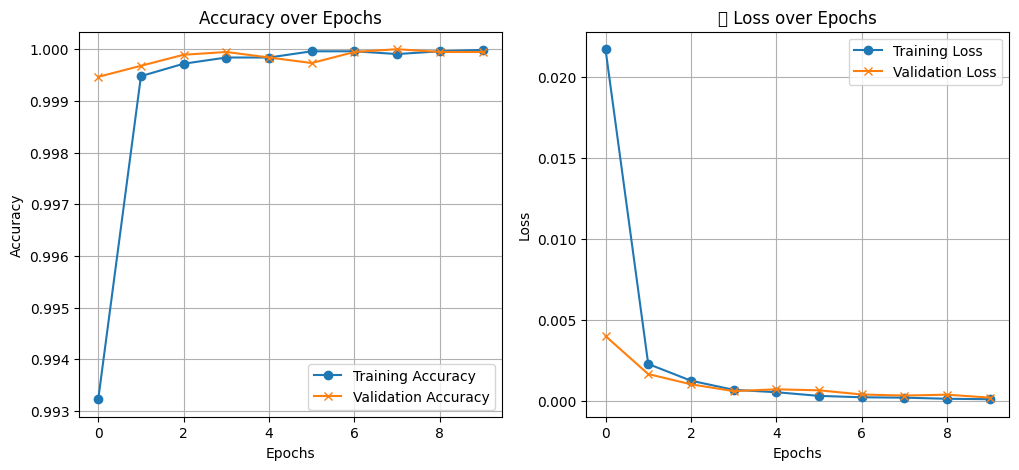

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title("Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title("📉 Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import json

# Save class label mapping
label_map = train_gen.class_indices
with open("/content/label_map.json", "w") as f:
    json.dump(label_map, f)

print("Label map saved as /content/label_map.json")
print(label_map)

Label map saved as /content/label_map.json
{'food': 0, 'non_food': 1}


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


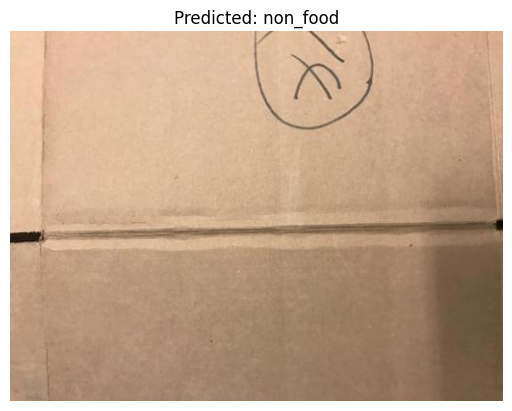

Model prediction: non_food


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Path to any test image (inside or outside dataset)
test_img_path = "/content/food_waste_dataset/non_food/cardboard/cardboard1.jpg"

# Load and preprocess
img = image.load_img(test_img_path, target_size=(128, 128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
predicted_class = list(train_gen.class_indices.keys())[np.argmax(pred)]

# Display
plt.imshow(image.load_img(test_img_path))
plt.axis('off')
plt.title(f"Predicted: {predicted_class}")
plt.show()

print("Model prediction:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


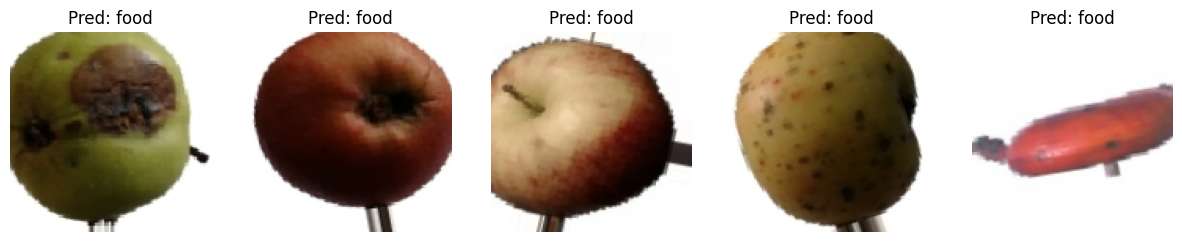

In [ ]:
import random

# Pick 5 random test images from the validation set
batch = next(val_gen)
images, labels = batch

plt.figure(figsize=(15, 8))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    img = images[i]
    label = np.argmax(labels[i])
    pred = np.argmax(model.predict(img[np.newaxis, ...]))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Pred: {list(train_gen.class_indices.keys())[pred]}")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


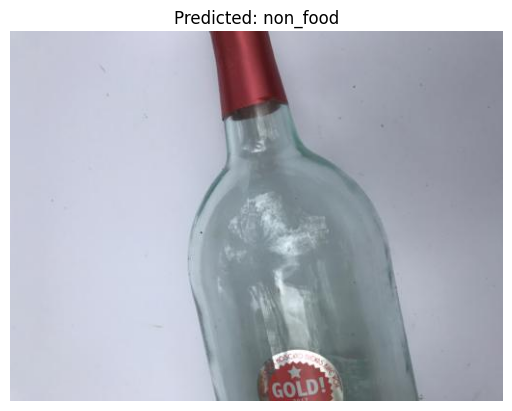

Model prediction: non_food


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Path to any test image (inside or outside dataset)
test_img_path = "/content/food_waste_dataset/non_food/glass/glass103.jpg"

# Load and preprocess
img = image.load_img(test_img_path, target_size=(128, 128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
predicted_class = list(train_gen.class_indices.keys())[np.argmax(pred)]

# Display
plt.imshow(image.load_img(test_img_path))
plt.axis('off')
plt.title(f"Predicted: {predicted_class}")
plt.show()

print("Model prediction:", predicted_class)

585/585 ━━━━━━━━━━━━━━━━━━━━ 82s 139ms/step


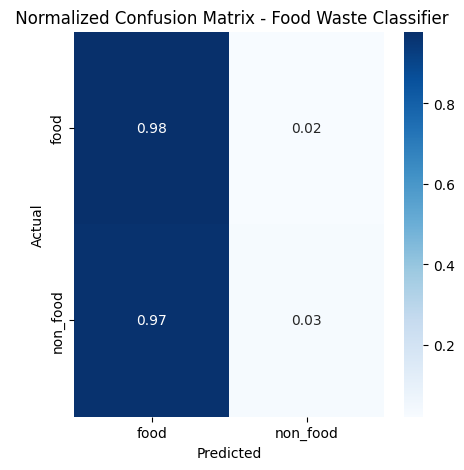


 Classification Report:

              precision    recall  f1-score   support

        food       0.98      0.98      0.98     18302
    non_food       0.03      0.03      0.03       403

    accuracy                           0.96     18705
   macro avg       0.51      0.51      0.51     18705
weighted avg       0.96      0.96      0.96     18705



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get ground truth and predictions from validation set
y_true = val_gen.classes
y_pred = np.argmax(model.predict(val_gen, verbose=1), axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Normalize the confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot heatmap
plt.figure(figsize=(5, 5))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=list(val_gen.class_indices.keys()),
            yticklabels=list(val_gen.class_indices.keys()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(' Normalized Confusion Matrix - Food Waste Classifier')
plt.show()

# Step 5: Print classification report
print("\n Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=list(val_gen.class_indices.keys())))
